In [1]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
rfm=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\rfm.parquet")
customer_value_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_value_segments.parquet")
order_enriched=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\order_enriched.parquet")


c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  currencyexchange = pd.read_sql("SELECT * FROM currencyexchange", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer = pd.read_sql("SELECT * FROM customer", conn)
c:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\db_setup.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  date = pd.read_sql("SELECT * FR

Cohort_base

In [2]:
#to get our base we need the order_enriched that has one order per row
cohort=order_enriched.merge(
    customer_summary[["customerkey","cohort_month"]],
    on="customerkey"
)

cohort["order_month"] = cohort["orderdate"].dt.to_period("M")
cohort["cohort_month"] = cohort["cohort_month"].dt.to_period("M")

cohort

,orderkey,orderdate,delivery_date,customerkey,storekey,line_count,distinct_products,total_units,order_revenue,order_cost,...,occupation,birthday,customer_name,store_country,store_state,store_status,squaremeters,age_at_order,cohort_month,order_month
0,1000,2015-01-01,2015-01-01,947009,400,2,2,2,1182.677889,685.196010,...,Computer hardware engineer,1994-01-23,Hayden Rowe,United Kingdom,Dungannon and South Tyrone,None,1300.0,20,2015-01,2015-01
1,1001,2015-01-01,2015-01-01,1772036,430,1,1,2,108.752000,50.008000,...,Letterpress setter,1970-12-03,Beverly Tejeda,United States,Alaska,None,1190.0,44,2015-01,2015-01
2,1002,2015-01-01,2015-01-01,1518349,660,4,4,15,3458.642260,1738.882000,...,Leasing consultant,1940-04-21,Kristi Daniel,United States,West Virginia,None,1785.0,74,2015-01,2015-01
3,1003,2015-01-01,2015-01-01,1317097,510,1,1,3,224.977500,103.455000,...,Range scientist,1991-04-26,Richard Holland,United States,Maine,None,1295.0,23,2015-01,2015-01
4,1004,2015-01-01,2015-01-01,254117,80,4,4,5,2419.632568,904.326130,...,Cinematographer,1945-01-22,Jack Gabor,Canada,Newfoundland and Labrador,None,2105.0,69,2015-01,2015-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83125,3398031,2024-04-20,2024-04-20,1692049,530,4,4,13,2624.342200,1301.730000,...,Skills training coordinator,1948-05-08,George Wilson,United States,Montana,None,1260.0,75,2020-02,2024-04
83126,3398032,2024-04-20,2024-04-25,852158,999999,2,2,3,312.848194,165.217854,...,Organic chemist,1948-11-19,Guus Doodeman,Online,Online,None,NaN,75,2022-09,2024-04
83127,3398033,2024-04-20,2024-04-20,635184,160,3,3,13,5235.110046,1959.241504,...,Director,1955-01-04,Virginie Patel,France,Limousin,None,385.0,69,2015-02,2024-04
83128,3398034,2024-04-20,2024-04-21,664396,999999,3,3,9,1420.644615,739.181847,...,Media specialist,1982-02-02,Karlotta Rivière,Online,Online,None,NaN,42,2024-04,2024-04


cohort months after first purchase:

In [3]:
cohort["months_number"]=(
    (cohort["order_month"].dt.year*12 + cohort["order_month"].dt.month)
    -
    (cohort["cohort_month"].dt.year*12 + cohort["cohort_month"].dt.month)
)

In [4]:
cohort.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83130 entries, 0 to 83129
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   orderkey           83130 non-null  int64         
 1   orderdate          83130 non-null  datetime64[ns]
 2   delivery_date      83130 non-null  datetime64[ns]
 3   customerkey        83130 non-null  int64         
 4   storekey           83130 non-null  int64         
 5   line_count         83130 non-null  int64         
 6   distinct_products  83130 non-null  int64         
 7   total_units        83130 non-null  int64         
 8   order_revenue      83130 non-null  float64       
 9   order_cost         83130 non-null  float64       
 10  order_profit       83130 non-null  float64       
 11  delivery_days      83130 non-null  int64         
 12  customer_country   83130 non-null  object        
 13  gender             83130 non-null  object        
 14  age   

Retention table:

In [5]:
cohort_count=(
    cohort
    .groupby(["cohort_month","months_number"])
    .agg(
        active_customers=("customerkey","nunique"),
        cohort_revenue=("order_revenue","sum"),
        cohort_profit=("order_profit","sum")
        )
    .reset_index()
)

cohort_count["cohort_revenue"]=cohort_count["cohort_revenue"].round(2)
cohort_count["cohort_profit"] = cohort_count["cohort_profit"].round(2)

cohort_count

,cohort_month,months_number,active_customers,cohort_revenue,cohort_profit
0,2015-01,0,200,492333.08,280261.46
1,2015-01,1,1,139.45,61.82
2,2015-01,5,1,830.25,359.92
3,2015-01,7,1,312.10,135.30
4,2015-01,8,1,3890.99,2176.55
...,...,...,...,...,...
5598,2024-02,1,10,24790.02,13963.43
5599,2024-02,2,4,9725.71,5959.16
5600,2024-03,0,292,531406.81,296640.91
5601,2024-03,1,1,595.43,314.64


cohort size:

In [ ]:
#why customer_summary and not order_enriched:
#order_enriched contains multiple rows per customer 
#customer_summary is one row per customer and already has the first_purchase_date. just like in sql.


cohort_size =( 
    customer_summary 
    .groupby("cohort_month")
    .agg(cohort_size=("customerkey", "nunique")) 
    .reset_index() 
)

cohort_size["cohort_month"] = cohort_size["cohort_month"].dt.to_period("M")

cohort_size

,cohort_month,cohort_size
0,2015-01,200
1,2015-02,290
2,2015-03,138
3,2015-04,77
4,2015-05,235
...,...,...
107,2023-12,515
108,2024-01,442
109,2024-02,595
110,2024-03,292


merge cohort_count and _size  and get the retention rate:

In [7]:
cohort_activity = cohort_count.merge(
    cohort_size,
    on="cohort_month"
)

cohort_activity["monthly_activity_rate"] = (
    cohort_activity["active_customers"] /
    cohort_activity["cohort_size"]
)

cohort_activity

,cohort_month,months_number,active_customers,cohort_revenue,cohort_profit,cohort_size,monthly_activity_rate
0,2015-01,0,200,492333.08,280261.46,200,1.000000
1,2015-01,1,1,139.45,61.82,200,0.005000
2,2015-01,5,1,830.25,359.92,200,0.005000
3,2015-01,7,1,312.10,135.30,200,0.005000
4,2015-01,8,1,3890.99,2176.55,200,0.005000
...,...,...,...,...,...,...,...
5598,2024-02,1,10,24790.02,13963.43,595,0.016807
5599,2024-02,2,4,9725.71,5959.16,595,0.006723
5600,2024-03,0,292,531406.81,296640.91,292,1.000000
5601,2024-03,1,1,595.43,314.64,292,0.003425


Heatmap:

In [ ]:

cohort_activity_pivot=cohort_activity.pivot_table(index="cohort_month",columns="months_number",values="monthly_activity_rate")
cohort_activity_pivot=cohort_activity_pivot*100
cohort_activity_pivot=cohort_activity_pivot.sort_index()
cohort_activity_pivot



months_number,0,1,2,3,4,5,6,7,8,9,...,102,103,104,105,106,107,108,109,110,111
cohort_month,,,,,,,,,,,,,,,,,,,,,
2015-01,100.0,0.500000,NaN,NaN,NaN,0.500000,NaN,0.500000,0.500000,NaN,...,0.500000,1.000000,0.500000,NaN,1.500000,1.500000,1.500000,1.500000,0.500000,0.5
2015-02,100.0,0.344828,NaN,0.344828,NaN,NaN,0.344828,0.344828,0.689655,NaN,...,2.758621,1.379310,1.034483,1.034483,0.344828,1.034483,2.758621,0.689655,0.689655,NaN
2015-03,100.0,0.724638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.724638,2.173913,0.724638,NaN,2.898551,1.449275,0.724638,NaN,NaN,NaN
2015-04,100.0,NaN,NaN,NaN,NaN,2.597403,NaN,1.298701,NaN,NaN,...,1.298701,3.896104,2.597403,1.298701,7.792208,1.298701,NaN,NaN,NaN,NaN
2015-05,100.0,0.425532,0.425532,0.425532,0.425532,NaN,NaN,0.425532,0.851064,0.851064,...,2.127660,2.127660,1.702128,1.276596,0.425532,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12,100.0,2.912621,2.330097,0.970874,0.388350,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01,100.0,2.036199,1.357466,0.226244,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-02,100.0,1.680672,0.672269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
cohort_activity_pivot.describe()

months_number,0,1,2,3,4,5,6,7,8,9,...,102,103,104,105,106,107,108,109,110,111
count,112.0,92.000000,92.000000,88.000000,89.000000,82.000000,87.000000,86.000000,89.000000,83.000000,...,10.000000,9.000000,7.000000,4.000000,6.000000,4.000000,3.000000,2.000000,2.000000,1.0
mean,100.0,1.383789,1.323701,1.340967,1.343701,1.478409,1.370889,1.336482,1.172656,1.258162,...,1.315046,2.040412,1.250327,1.432106,2.372051,1.320615,1.661086,1.094828,0.594828,0.5
std,0.0,0.883992,0.818206,0.822196,0.842510,0.924196,0.812841,0.880445,0.692520,0.848123,...,0.718293,1.212366,0.801862,0.473082,2.811628,0.209033,1.026515,0.573000,0.134106,NaN
min,100.0,0.246305,0.263852,0.120048,0.149925,0.233100,0.238663,0.147493,0.156495,0.168919,...,0.500000,0.370370,0.423729,1.034483,0.344828,1.034483,0.724638,0.689655,0.500000,0.5
25%,100.0,0.655795,0.684464,0.643172,0.654664,0.802409,0.712611,0.686771,0.543478,0.585661,...,0.728663,1.379310,0.612319,1.216067,0.636946,1.232647,1.112319,0.892241,0.547414,0.5
50%,100.0,1.190019,1.253922,1.215641,1.200480,1.315211,1.197605,1.253253,1.032258,1.000000,...,1.301525,1.739130,1.034483,1.287649,1.385593,1.373988,1.500000,1.094828,0.594828,0.5
75%,100.0,1.942174,1.776872,1.877280,1.912568,1.987587,2.044299,1.794727,1.680672,1.774916,...,1.603045,2.173913,1.736020,1.503687,2.548913,1.461957,2.129310,1.297414,0.642241,0.5
max,100.0,4.519774,3.741935,3.506494,3.472222,5.309735,3.432494,5.248619,3.000000,3.539823,...,2.758621,3.982301,2.597403,2.118644,7.792208,1.500000,2.758621,1.500000,0.689655,0.5


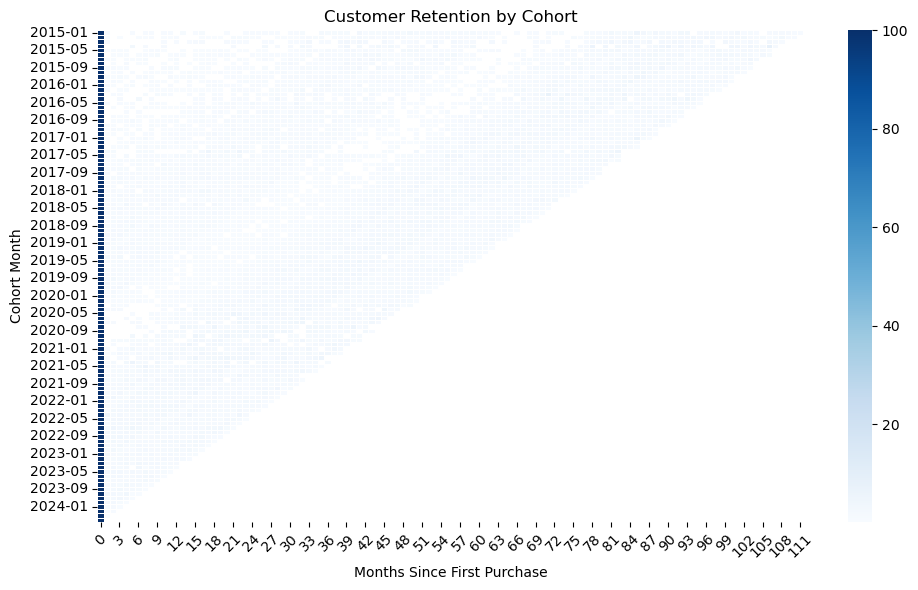

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    cohort_activity_pivot,
    annot=False,
    #to write the value inside the cell
    fmt=".0%",
    cmap="Blues",
    linewidths=0.5
)

plt.xticks(rotation=45)
plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()


C:\Users\amyre\AppData\Local\Temp\ipykernel_35464\751648110.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


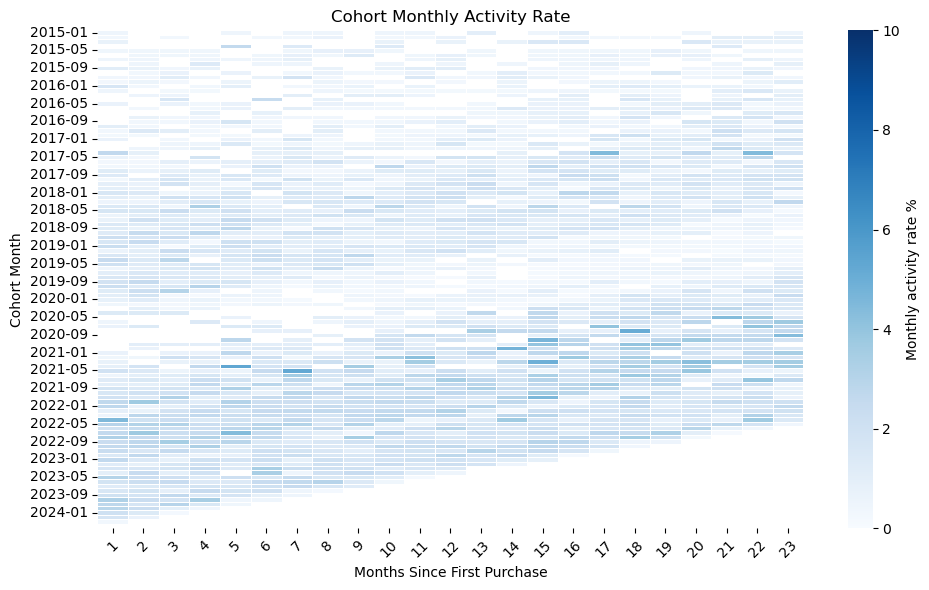

In [ ]:
#the same but i removed month 0. it's always 100%.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    cohort_activity_pivot.iloc[:,1:24],
    annot=False,
    cmap="Blues",
    linewidths=0.5,
    vmin=0,
    vmax=10
)

plt.gca().collections[0].colorbar.set_label("Monthly activity rate %")


plt.xticks(rotation=45)
plt.title("Cohort Monthly Activity Rate")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.legend().set_visible(False)
plt.tight_layout()

Cohort lifetime avg profit:

In [12]:
cohort_profit = (
    customer_summary
    .groupby("cohort_month")
    .agg(
        customers=("customerkey","count"),
        avg_lifetime_profit=("lifetime_profit","mean"),
        total_profit=("lifetime_profit","sum")
    )
    .reset_index()
)

cohort_profit

,cohort_month,customers,avg_lifetime_profit,total_profit
0,2015-01-01,200,2840.743882,568148.776349
1,2015-02-01,290,3073.931645,891440.176921
2,2015-03-01,138,3104.844484,428468.538755
3,2015-04-01,77,3088.630252,237824.529407
4,2015-05-01,235,2948.427699,692880.509272
...,...,...,...,...
107,2023-12-01,515,1040.984958,536107.253329
108,2024-01-01,442,1108.869942,490120.514518
109,2024-02-01,595,1109.145889,659941.804249
110,2024-03-01,292,1016.971058,296955.548892


Plot:

Text(0, 0.5, 'Average Lifetime Profit USD')

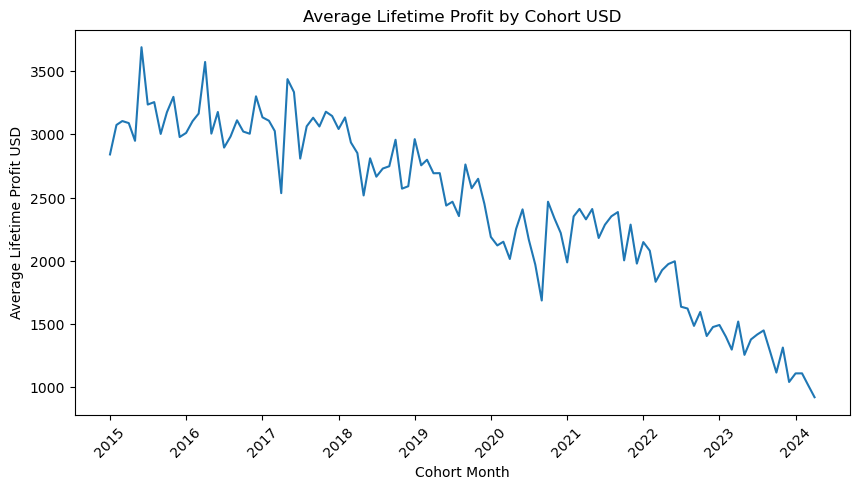

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    cohort_profit["cohort_month"],
    cohort_profit["avg_lifetime_profit"]
)

plt.xticks(rotation=45)

plt.title("Average Lifetime Profit by Cohort USD")
plt.xlabel("Cohort Month")
plt.ylabel("Average Lifetime Profit USD")

